# Fantasy Football Hierarchical Bayesian Inference

## Imports

In [110]:
import os.path
import math
import pickle
import nfldb
import matplotlib.pyplot as plt
from pylab import rcParams
%matplotlib inline
%config InlineBackend.figure_format = 'png'
import seaborn as sns
import numpy as np
import pandas as pd
import theano.tensor as tt
import pymc3 as pm
import scipy as sp
from scipy import optimize
import scipy.stats as st
from IPython.core.debugger import Tracer;

## Data Import and Munging

### nfldb
Create data base with metrics for the 2015 regular season with nfldb

In [111]:
df_track = pd.DataFrame()
score_diff = np.empty([1,2])
bet_frac = []
win_frac = []
dum_frac = []
dst_list = []
cor_frac = []
tot_bets = 0;
tot_wins = 0;

In [131]:
from nfldbim import nfldbim, nfldbi
from spread import spread
    
# specify inputs
season_year = 2013
K = 1
#for season_year in range(2013, 2018):
num_simulations = 5000
fname = `season_year`+'_'+`K`+'.pickle'
print(fname)
if os.path.isfile(fname):
    with open(fname, 'rb') as handle:
        record, df, teams = pickle.load(handle)
else:
    record = pd.DataFrame()
    for week in range(1,18):
        print(week)
        df, teams = nfldbim(season_year, range(1, week+1))
        record = pd.concat([record, spread(df, week, num_simulations)])
        print(record)
    with open(fname, 'wb') as handle: 
        pickle.dump([record, df, teams], handle, protocol=pickle.HIGHEST_PROTOCOL)

2013_1.pickle


In [132]:
win_loss = np.array([])
weeks = np.array([])
odds = np.array([])

rmse_me = []
rmse_or = []

# spread for the year (file generated from cbs_scraper.)

df_spread = pd.read_csv("../ruby_scrapers/spread.csv", sep=',', delimiter=None, header='infer')

for week in range(1, 18):
    # this weeks games
    df_w = df[df.week == week].copy()
    num_games = float(df_w.shape[0])

    # vegas spread.
    df_sw = df_spread[(df_spread.week==week) & (df_spread.year==season_year)]
    
    # merge spread with weekly weekly data
    df_w = pd.merge(df_w,
                    df_sw[['home_team','home_spread']],
                    on='home_team')

    # simulations of all games this week
    week_record_home = record[record.week == week][df_w.home_team.values]
    week_record_away = record[record.week == week][df_w.away_team.values]

    # compute spread for each simulation
    week_record = week_record_home  - week_record_away.values
    week_spread = week_record[df_w.home_team] + df_w.home_spread.values

    # mean predicted spread
    df_w['pred_spread'] = week_spread.median().values

    # compute odds that the home team wins
    df_w['odds_home_win'] = (week_record[df_w.home_team]
                                   > 0).mean().values

    # compute odds that the home team wins against the spread
    df_w['odds_home'] = (week_spread[df_w.home_team]
                               > 0).mean().values

    # should we bet on home and what are the odds that we win the bet
    df_w['bet_on_home'] = df_w.apply(lambda x:
                                     x.odds_home > 0.5,
                                     axis=1)

    df_w['odds_win'] = df_w.apply(lambda x:
                                  np.abs(x.odds_home - 0.5) + 0.5,
                                  axis=1)
    
    # set all nans to zero probability
    df_w.loc[np.isnan(df_w.home_spread),'odds_win'] = 0

    # find true spread from game outcome
    df_w['true_spread'] = df_w.apply(lambda x:
                                     x.away_score - x.home_score,
                                     axis=1)    

    # does home win against the spread?
    df_w['home_win'] = df_w.apply(lambda x:
                                  x.home_score - x.away_score + x.home_spread > 0,
                                  axis=1)

    # would we have won this bet
    df_w['win_bet'] = df_w.bet_on_home == df_w.home_win

    df_w['win'] = (df_w.odds_home_win>0.5) == df_w.home_win

    # crac
    cor_frac.append(df_w.win.mean())

    # compute fraction of games won
    win_frac.append(df_w.win_bet.mean())

    # what if i only take high probability bets
    df_best_odds = df_w[(df_w.odds_win<1) & (df_w.odds_win>0.65)].copy()
    
    # odds for best bets
    bet_frac.append([df_best_odds.win_bet.mean(), week ])
    a = np.append(df_w.home_score.values - week_record_home.mean().values,
    df_w.away_score.values - week_record_away.mean().values)
    b = np.array([a, week*np.ones(len(a))]).transpose()
    score_diff = np.append(score_diff,b, axis=0)

    tot_wins += sum(df_best_odds.win_bet)
    
    # track how many of these bets we make
    tot_bets += df_best_odds.shape[0]

    # track win loss
    win_loss = np.hstack([win_loss, df_best_odds.win_bet.values])
    weeks = np.hstack([weeks, week*np.ones(len(df_best_odds))])
    odds = np.hstack([odds, df_best_odds.odds_win.values])

    # track likelyhood of outcome
    mu = week_record[df_w.home_team].mean()
    sd = week_record[df_w.home_team].std()
    dist = st.norm(mu, sd)
    dst_list.append( dist.cdf(df_w.true_spread) )

    rmse_me.append(((week_record[df_w.home_team] - df_w.true_spread.values)**2).mean().mean()**.5)
    #df_track = df_track.append(df_w[['odds_win','win_bet']])
    df_track = df_track.append(df_w)

[0.55000000000000004, 125]
[0.61428571428571432, 92]
[0.6785714285714286, 104]
[0.74285714285714288, 81]
[0.80714285714285716, 74]
[0.87142857142857144, 64]
[0.93571428571428572, 35]
[1.0, 20]


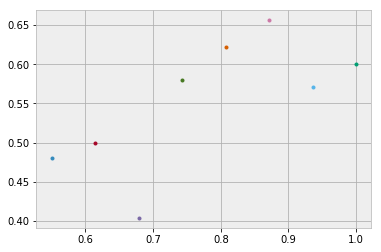

In [133]:
for p in np.linspace(0.55, 1., 8):
    outcome = df_track[(df_track.odds_win < p) & (df_track.odds_win > p-.05)].win_bet
    mu = np.mean(outcome)
    print([p, len(outcome) ])
    plt.plot(p, mu,'.')
plt.show()

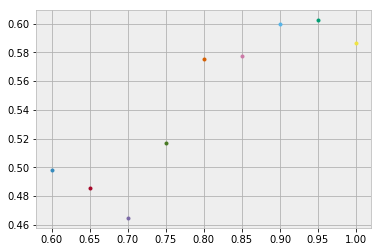

In [134]:
for p in np.linspace(0.6, 1., 9):
    mu = np.mean(df_track[(df_track.odds_win < p) & (df_track.odds_win > p-.1)].win_bet)
    plt.plot(p, mu,'.')
plt.show()

In [135]:
r = pd.DataFrame({'WIN':win_frac, 
                  'BET':bet_frac,
                  'COR':cor_frac})

print(r.mean())
print(tot_bets)
print(r)

COR    0.534316
WIN    0.528023
dtype: float64
430
                     BET       COR       WIN
0    [0.785714285714, 1]  0.812500  0.750000
1    [0.416666666667, 2]  0.375000  0.500000
2    [0.727272727273, 3]  0.812500  0.687500
3    [0.888888888889, 4]  0.733333  0.600000
4             [0.625, 5]  0.571429  0.571429
5              [0.25, 6]  0.400000  0.333333
6    [0.555555555556, 7]  0.600000  0.666667
7             [0.625, 8]  0.692308  0.461538
8               [0.5, 9]  0.461538  0.384615
9            [0.375, 10]  0.285714  0.428571
10  [0.555555555556, 11]  0.600000  0.666667
11  [0.555555555556, 12]  0.428571  0.500000
12             [0.6, 13]  0.562500  0.562500
13             [0.5, 14]  0.500000  0.375000
14  [0.777777777778, 15]  0.500000  0.812500
15  [0.666666666667, 16]  0.375000  0.500000
16  [0.714285714286, 17]  0.750000  0.687500
17   [0.545454545455, 1]  0.500000  0.500000
18   [0.461538461538, 2]  0.437500  0.437500
19   [0.454545454545, 3]  0.500000  0.500000
20  

In [136]:
print(float(tot_wins)/tot_bets)
# 61%
bet_fracnp = np.array(bet_frac)
s = pd.DataFrame(score_diff[1:,:])

0.558139534884


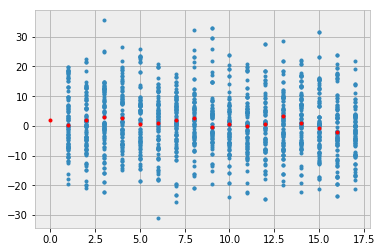

In [137]:
plt.plot(s.values[:,1],s.values[:,0],'.')
plt.plot(s.groupby(1).mean().values,'.r')

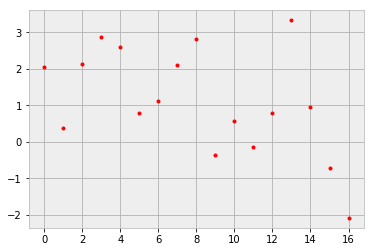

In [138]:
plt.plot(s.groupby(1).mean().values,'.r')

In [129]:
s

,0,1
0,9.8220,1.0
1,2.0686,1.0
2,17.7996,1.0
3,15.0418,1.0
4,13.1394,1.0
5,-10.3740,1.0
6,-7.5818,1.0
7,-11.7672,1.0
8,-10.3116,1.0
9,-1.0840,1.0


In [130]:
summary_fname = 'win_loss_'+`season_year`+'.pickle';
with open(summary_fname, 'wb') as handle: 
    pickle.dump([win_loss, weeks, odds], handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
win_loss = np.array([])
weeks = np.array([])
odds = np.array([])

for year in range(2013,2018):
    summary_fname = 'win_loss_'+`year`+'.pickle';
    with open(summary_fname, 'rb') as handle:
        wi, wk, oi = pickle.load(handle)
        win_loss = np.hstack([win_loss, wi])
        weeks = np.hstack([weeks, wk])
        odds  = np.hstack([odds, oi])

In [ ]:
def find_posterior(samples, alpha=2, beta=2, ax=None):
    heads = sum(samples == 1)
    tails = sum(samples == 0)
    x = np.linspace(0, 1, 1000)
    y = sp.stats.beta.pdf(x, heads+alpha, tails+beta)
    
    y = y/y.sum()
    if not ax:
        fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_xlabel(r"$\theta$", fontsize=20)
    ax.set_ylabel(r"$P(\theta|D)$", fontsize=20)
    ax.set_title("Posterior after {} heads, {} tails, \
                 Prior: BetaPDF({},{})".format(heads, tails, alpha, beta));
    return x, y

In [ ]:
p, post = find_posterior(win_loss)
print( post[p > .5].sum() )

In [ ]:
plt.plot(odds, win_loss,'.')

In [ ]:
plt.hist(odds[win_loss ==1])
plt.hist(odds[win_loss ==0], alpha=0.4)
plt.show()

In [ ]:
for i in [[odds<0.65],[(odds>0.65) & (odds<75)],[(odds>0.75)]]:
    print(win_loss[i].mean())

In [ ]:
plt.plot(win_loss, weeks, '.')

In [ ]:
x = []
for week in range(2,18):
    x.append( win_loss[weeks==week].mean())

In [ ]:
plt.plot(x,'.') 